# S3 hammer pulse spectrum

3C6 Section 3: spectrum of impulse hammer input

## imports and definitions

In [1]:
import numpy as np
import scipy.signal as ss
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation
matplotlib.rcParams.update({'font.size': 12,'font.family':'serif'})
from ipywidgets import interact
import time

In [2]:
%matplotlib widget

## Setup parameters

In [3]:
# Set up parameters
T_pulse = 0.01
fs = 50/T_pulse # Hz

T_full = 1
t = np.arange(0,T_full,1/fs)

# Simulate hammer pulse
freq = 1/(2*T_pulse)
f = np.sin(2*np.pi*freq * t)
f[t>T_pulse] = 0

In [4]:
# Simulate low pass filter
fcL = fs/10
[bL,aL]=ss.butter(5,fcL/(fs/2))
f_LPF = ss.lfilter(bL,aL,f)

# Simulate high pass filter
fcH = 2
[bH,aH] = ss.butter(1,fcH/(fs/2),'high')
f_HPF = ss.lfilter(bH,aH,f)

# Simulate combined effect
f_observed = ss.lfilter(bH,aH,f_LPF)

# Fourier Transform
N = len(t)
frequency_axis = np.fft.rfftfreq(N,1/fs)
F = np.fft.rfft(f)
F_observed = np.fft.rfft(f_observed)

In [ ]:
# Plot time
plt.figure(figsize=(9,5),dpi=100) # width, height in inches
plt.grid()
plt.xlabel('Time (s)')
plt.ylabel('f(t)')
L1 = plt.plot(t,f,'-',linewidth=2,label="ideal",alpha=True)
L3 = plt.plot(t,f_HPF,'-',linewidth=2,label="HPF",alpha=False)
L2 = plt.plot(t,f_LPF,'-',linewidth=2,label="LPF",alpha=False)
L4 = plt.plot(t,f_observed,'-',linewidth=2,label="observed",alpha=False)

plt.legend()
def plot(ideal,HPF,LPF,observed):
    L1[0].set_alpha(ideal)
    L2[0].set_alpha(LPF)
    L3[0].set_alpha(HPF)
    L4[0].set_alpha(observed)
    plt.legend()
    plt.draw()
    plt.show()
    
interact(plot, ideal=True, HPF=False, LPF=False, observed=False)

interactive(children=(Checkbox(value=True, description='ideal'), Checkbox(value=False, description='HPF'), Che…

<function __main__.plot(ideal, HPF, LPF, observed)>

interactive(children=(Checkbox(value=True, description='ideal'), Checkbox(value=False, description='observed')…

<function __main__.plotfft(ideal, observed)>

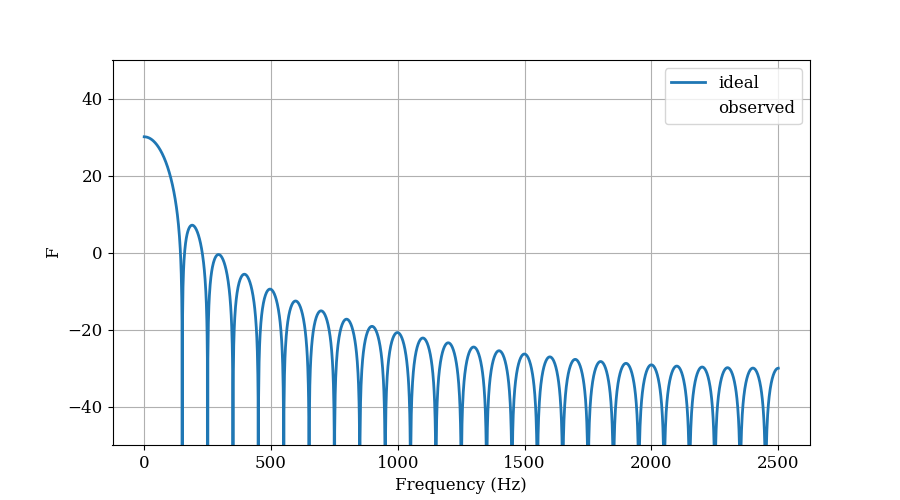

In [6]:
# Plot time
plt.figure(figsize=(9,5),dpi=100) # width, height in inches
plt.grid()
plt.xlabel('Frequency (Hz)')
plt.ylabel('F')
L1fft = plt.plot(frequency_axis,20*np.log10(np.abs(F)),'-',linewidth=2,label="ideal",alpha=True)
L2fft = plt.plot(frequency_axis,20*np.log10(np.abs(F_observed)),'-',linewidth=2,label="observed",alpha=False)
plt.ylim([-50,50])
plt.legend()

def plotfft(ideal,observed):
    L1fft[0].set_alpha(ideal)
    L2fft[0].set_alpha(observed)
    plt.legend()
    
interact(plotfft, ideal=True, observed=False)